In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv('https://gist.githubusercontent.com/curran/4b59d1046d9e66f2787780ad51a1cd87/raw/9ec906b78a98cf300947a37b56cfe70d01183200/data.tsv', sep='\t')
data.head()

,eruptions,waiting
0,3.600,79
1,1.800,54
2,3.333,74
3,2.283,62
4,4.533,85


<Axes: xlabel='eruptions', ylabel='waiting'>

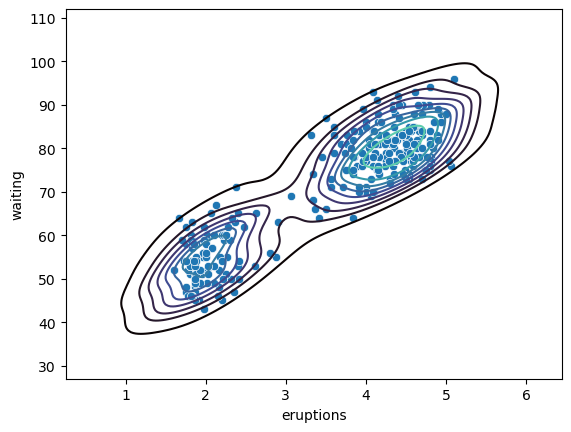

In [3]:
sns.kdeplot(data=data,
            x='eruptions',
            y='waiting',
            thresh=0.05,
            levels=10,cmap='mako')
sns.scatterplot(data=data, x='eruptions', y='waiting')

In [4]:
from sklearn.mixture import GaussianMixture

In [5]:
eruptions = np.array(data['eruptions'].tolist())

# For univariate data
gmm = GaussianMixture(n_components=2)
gmm.fit(eruptions.reshape(-1, 1))

means = gmm.means_.flatten()
variances = gmm.covariances_.flatten()
standard_devs = np.sqrt(variances)
mixing_proportions = gmm.weights_

print("Means:", means)
print("Standard Deviations:", standard_devs)
print("Mixing Proportions:", mixing_proportions)

Means: [4.27765668 2.02324346]
Standard Deviations: [0.43059386 0.24300493]
Mixing Proportions: [0.64963229 0.35036771]


In [6]:
waiting = np.array(data['waiting'].tolist())

# For univariate data
gmm = GaussianMixture(n_components=2)
gmm.fit(waiting.reshape(-1, 1))

means = gmm.means_.flatten()
variances = gmm.covariances_.flatten()
standard_devs = np.sqrt(variances)
mixing_proportions = gmm.weights_

print("Means:", means)
print("Standard Deviations:", standard_devs)
print("Mixing Proportions:", mixing_proportions)

Means: [80.14546556 54.69984271]
Standard Deviations: [5.81293521 5.94286542]
Mixing Proportions: [0.63654233 0.36345767]


## Multivariate

In [7]:
# For multivariate data (e.g., eruptions and waiting)
gmm = GaussianMixture(n_components=2, random_state=0)
gmm.fit(data[['eruptions', 'waiting']])

GaussianMixture(n_components=2, random_state=0)

In [8]:
# Accessing the parameters
means = gmm.means_
covariances = gmm.covariances_
weights = gmm.weights_

print("Means:\n", means)
print("\nCovariances:\n", covariances)
print("\nMixing Proportions:\n", weights)

Means:
 [[ 2.03652149 54.47986018]
 [ 4.28977944 79.96953298]]

Covariances:
 [[[ 0.06927449  0.43627723]
  [ 0.43627723 33.70493352]]

 [[ 0.16982046  0.93871793]
  [ 0.93871793 36.02497019]]]

Mixing Proportions:
 [0.35592745 0.64407255]
